### Importing Initial Libraries & Data Prep, cleaning.

In [174]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path


pd.set_option('display.max_rows', 100000)

In [175]:

excel_path = Path("Model.xlsx")

df = pd.read_excel(excel_path, sheet_name="Model", engine="openpyxl",index_col=0)
df = df.round(1)
#df = df.iloc[:-1,:]
df.head(5)

,GDP,Oil_Rev,Non_Oil_Rev,GovEx,CAPEX,PMI,POS,Oil_Price,Oil_Production,M3,Exports
Date,,,,,,,,,,,
2017-03-31,932702.0,115100.0,29000.0,170300.0,9300.0,56.7,15358633.3,53.9,9898.0,1779430.4,207398.8
2017-06-30,922635.0,101000.0,62900.0,210400.0,34700.0,55.4,17061200.0,50.1,9948.0,1803423.0,189753.4
2017-09-30,933711.0,94300.0,47800.0,190900.0,24500.0,55.7,16125500.0,52.1,10005.0,1804225.9,196313.0
2017-12-31,985165.0,129500.0,112000.0,356400.0,101000.0,56.8,17518700.0,61.5,9992.7,1790167.3,238516.0
2018-03-31,958113.0,113900.0,52400.0,200600.0,25300.0,53.0,18472100.0,66.8,9955.3,1802989.5,244247.0


In [176]:
df = df[['GDP', 'PMI', 'Oil_Price', 'Oil_Production', 'M3', 'POS']]

### Inspecting Data

In [177]:
df.head(5)

,GDP,PMI,Oil_Price,Oil_Production,M3,POS
Date,,,,,,
2017-03-31,932702.0,56.7,53.9,9898.0,1779430.4,15358633.3
2017-06-30,922635.0,55.4,50.1,9948.0,1803423.0,17061200.0
2017-09-30,933711.0,55.7,52.1,10005.0,1804225.9,16125500.0
2017-12-31,985165.0,56.8,61.5,9992.7,1790167.3,17518700.0
2018-03-31,958113.0,53.0,66.8,9955.3,1802989.5,18472100.0


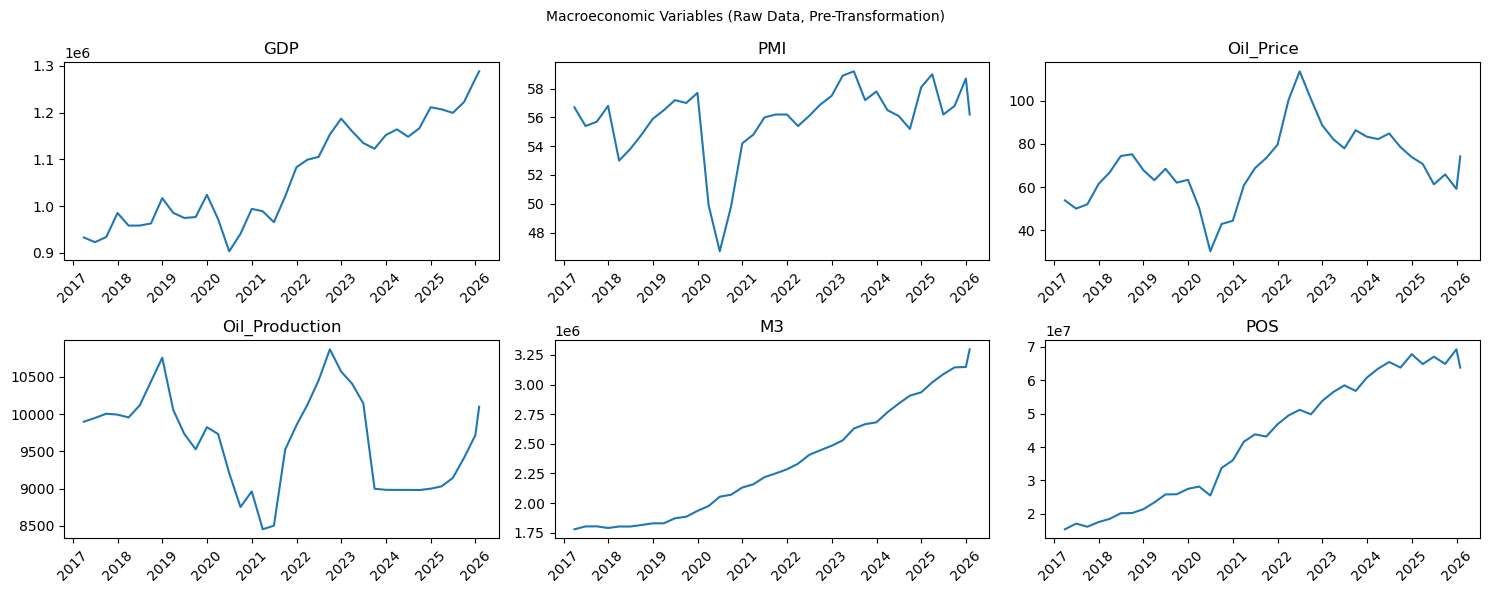

In [178]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
fig.suptitle('Macroeconomic Variables (Raw Data, Pre-Transformation)', fontsize=10)

# Define the columns to plot
columns_to_plot = ['GDP', 'PMI', 'Oil_Price', 'Oil_Production', 'M3', 'POS']


axes = axes.flatten()


for i, col in enumerate(columns_to_plot):
    axes[i].plot(df.index, df[col],color='tab:blue')
    axes[i].set_title(col)
    #axes[i].grid(True)
    axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis dates for readability

# Automatically adjust spacing to prevent overlapping titles/labels
plt.tight_layout()

plt.show()

### Stationarity Test

In [179]:
from statsmodels.tsa.stattools import adfuller


def run_adf_test(series, var_name):
    """
    Runs the Augmented Dickey-Fuller test on a time series and prints the interpretation.
    """
    print(f"{'='*50}")
    print(f"Augmented Dickey-Fuller Test for: {var_name}")
    print(f"{'='*50}")
    
    # We use dropna() so this exact function will still work later 
    # when you pass in differenced data (which creates NaN in the first row)
    # we used AIC for optimal lag length selection 
    result = adfuller(series.dropna(), autolag='AIC') 
    
    adf_statistic = result[0]
    p_value = result[1]
    critical_values = result[4]
    
    print(f"ADF Statistic: {adf_statistic:.4f}")
    print(f"p-value:       {p_value:.4f}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.4f}")
        
    print("-" * 50)
    
    # Automated Interpretation
    if p_value < 0.05:
        print(f"Interpretation: Strong evidence against the null hypothesis (p < 0.05).")
        print(f"Conclusion:     Reject the null hypothesis. The data is STATIONARY.\n")
    else:
        print(f"Interpretation: Weak evidence against the null hypothesis (p >= 0.05).")
        print(f"Conclusion:     Fail to reject the null hypothesis. The data is NON-STATIONARY.\n")

# Run the test on every column in your DataFrame
for column in df.columns:
    run_adf_test(df[column], column)

Augmented Dickey-Fuller Test for: GDP
ADF Statistic: 0.4856
p-value:       0.9844
Critical Values:
   1%: -3.6699
   5%: -2.9641
   10%: -2.6212
--------------------------------------------------
Interpretation: Weak evidence against the null hypothesis (p >= 0.05).
Conclusion:     Fail to reject the null hypothesis. The data is NON-STATIONARY.

Augmented Dickey-Fuller Test for: PMI
ADF Statistic: -3.2657
p-value:       0.0165
Critical Values:
   1%: -3.6327
   5%: -2.9485
   10%: -2.6130
--------------------------------------------------
Interpretation: Strong evidence against the null hypothesis (p < 0.05).
Conclusion:     Reject the null hypothesis. The data is STATIONARY.

Augmented Dickey-Fuller Test for: Oil_Price
ADF Statistic: -2.3557
p-value:       0.1546
Critical Values:
   1%: -3.6327
   5%: -2.9485
   10%: -2.6130
--------------------------------------------------
Interpretation: Weak evidence against the null hypothesis (p >= 0.05).
Conclusion:     Fail to reject the null 

### Transformation

In [180]:
# Separate your variables based on the ADF test results
non_stationary_cols = ['GDP', 'PMI', 'Oil_Price', 'M3', 'POS']
stationary_cols = ['Oil_Production']

# Create a New DataFrame to hold the model-ready data
df_transformed = pd.DataFrame(index=df.index)

# Apply the Log-Difference to the non-stationary variables
for col in non_stationary_cols:
    df_transformed[col] = np.log(df[col]).diff()

# Carry over the stationary variable exactly as it is
for col in stationary_cols:
    df_transformed[col] = df[col]

# Drop the first row (Q1 2017) 
# Differencing always results in a NaN for the very first observation
df_transformed = df_transformed.dropna()

print("Transformation complete. Here is the head of your stationary dataset:")

# Inspecting Results
print(df_transformed.head())

Transformation complete. Here is the head of your stationary dataset:
                 GDP       PMI  Oil_Price        M3       POS  Oil_Production
Date                                                                         
2017-06-30 -0.010852 -0.023195  -0.073109  0.013393  0.105129          9948.0
2017-09-30  0.011933  0.005401   0.039144  0.000445 -0.056405         10005.0
2017-12-31  0.053642  0.019556   0.165872 -0.007823  0.082867          9992.7
2018-03-31 -0.027843 -0.069244   0.082666  0.007137  0.052993          9955.3
2018-06-30  0.000138  0.014982   0.107753 -0.000251  0.087632         10116.3


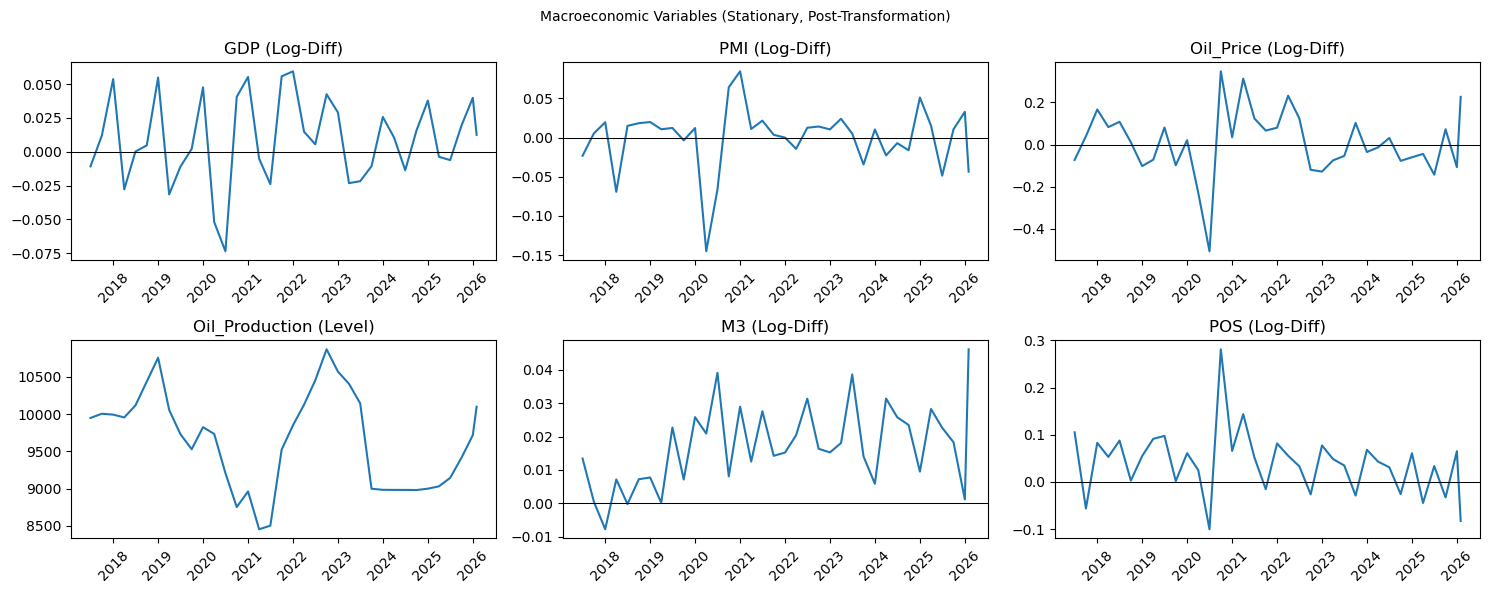

In [181]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
fig.suptitle('Macroeconomic Variables (Stationary, Post-Transformation)', fontsize=10)

# The columns to plot
columns_to_plot = ['GDP', 'PMI', 'Oil_Price', 'Oil_Production', 'M3', 'POS']

# Loop through the columns and plot
for i, col in enumerate(columns_to_plot):
    ax = axes[i//3, i%3]
    
 
    if col in ['Oil_Production']:    
        title = f"{col} (Level)"
    else:
        color = 'tab:orange'
        title = f"{col} (Log-Diff)"
# Note: Oil Production are in level        
    ax.plot(df_transformed.index, df_transformed[col], color="tab:blue")
    ax.set_title(title)
    #ax.grid(True)
    ax.tick_params(axis='x', rotation=45)
    
    # Add a zero line for the differenced variables to clearly see positive/negative growth
    if col != 'Oil_Production':
        ax.axhline(0, color='black', linewidth=0.75)

plt.tight_layout()
plt.show()

### Post Transformation Stationarity Test

In [182]:
def run_adf_test(series, var_name):
    print(f"{'='*50}")
    print(f"Augmented Dickey-Fuller Test for: {var_name}")
    print(f"{'='*50}")
    
    # ADF test
    result = adfuller(series, autolag='AIC') 
    
    adf_statistic = result[0]
    p_value = result[1]
    critical_values = result[4]
    
    print(f"ADF Statistic: {adf_statistic:.4f}")
    print(f"p-value:       {p_value:.4f}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.4f}")
        
    print("-" * 50)
    
    # Interpretation adjusted to highlight the 10% significance 
    if p_value < 0.05:
        print(f"Conclusion: STATIONARY at 5% significance level (p = {p_value:.4f}).\n")
    elif p_value < 0.10:
        print(f"Conclusion: STATIONARY at 10% significance level (p = {p_value:.4f}). Acceptable for Macro models.\n")
    else:
        print(f"Conclusion: NON-STATIONARY (p = {p_value:.4f}). Further differencing required.\n")

# Loop through the transformed columns
for column in df_transformed.columns:
    run_adf_test(df_transformed[column], column)

Augmented Dickey-Fuller Test for: GDP
ADF Statistic: -2.7833
p-value:       0.0607
Critical Values:
   1%: -3.6699
   5%: -2.9641
   10%: -2.6212
--------------------------------------------------
Conclusion: STATIONARY at 10% significance level (p = 0.0607). Acceptable for Macro models.

Augmented Dickey-Fuller Test for: PMI
ADF Statistic: -5.2986
p-value:       0.0000
Critical Values:
   1%: -3.6392
   5%: -2.9512
   10%: -2.6144
--------------------------------------------------
Conclusion: STATIONARY at 5% significance level (p = 0.0000).

Augmented Dickey-Fuller Test for: Oil_Price
ADF Statistic: -5.2750
p-value:       0.0000
Critical Values:
   1%: -3.6327
   5%: -2.9485
   10%: -2.6130
--------------------------------------------------
Conclusion: STATIONARY at 5% significance level (p = 0.0000).

Augmented Dickey-Fuller Test for: M3
ADF Statistic: -2.7036
p-value:       0.0734
Critical Values:
   1%: -3.6791
   5%: -2.9679
   10%: -2.6232
---------------------------------------

### Estimation

In [183]:
import statsmodels.api as sm
import itertools
import warnings
warnings.filterwarnings("ignore") # Suppress convergence warnings during the grid search

# Define your Endogenous (Target) and Exogenous (Predictor) variables
y = df_transformed['GDP']
X = df_transformed[['PMI', 'Oil_Price', 'Oil_Production', 'M3', 'POS']]

# Grid Search to find the best AR and MA lag orders (p and q)
# We test combinations from 0 to 2 lags. (d=0 because data is already stationary)
p = q = range(0, 3)
pq_combinations = list(itertools.product(p, q))

best_aic = float("inf")
best_order = None
best_model_results = None

print("Testing ARIMAX models...")
for order in pq_combinations:
    try:
        # We use SARIMAX from statsmodels as it handles exogenous variables perfectly
        model = sm.tsa.SARIMAX(endog=y, exog=X, order=(order[0], 0, order[1]))
        results = model.fit(disp=False)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (order[0], 0, order[1])
            best_model_results = results
    except:
        continue

print(f"\nOptimization Complete!")
print(f"Best ARIMAX Order (p, d, q): {best_order}")
print(f"Lowest AIC: {best_aic:.4f}\n")

# statistical summary of your winning model
print(best_model_results.summary())

Testing ARIMAX models...

Optimization Complete!
Best ARIMAX Order (p, d, q): (2, 0, 0)
Lowest AIC: -156.8234

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   36
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  86.412
Date:                Tue, 05 May 2026   AIC                           -156.823
Time:                        19:34:36   BIC                           -144.155
Sample:                             0   HQIC                          -152.402
                                 - 36                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
PMI                0.4386      0.166      2.641      0.008       0.113       0.764
Oil_Pric

In [184]:
import pandas as pd

#manually transformed Q1 2026 data
q1_2026_exog = pd.DataFrame({
   'PMI': [-0.0890],            
    'Oil_Price': [0.2570],      
    'Oil_Production': [9098],   
    'M3': [0.0538],              
    'POS': [-0.0827]           
}, index=['2026-03-31'])

#Generate the Q1 2026 GDP Growth Rate prediction
forecast_log_diff = best_model_results.forecast(steps=1, exog=q1_2026_exog)

print(f"Predicted Q1 2026 GDP (Log-Diff Growth): {forecast_log_diff.iloc[0]:.6f}")

Predicted Q1 2026 GDP (Log-Diff Growth): -0.036612


In [185]:
q1_2026_exog = pd.DataFrame({
    'PMI': [-0.0890],            
    'Oil_Price': [0.2570],      
    'Oil_Production': [9098],   
    'M3': [0.0538],              
    'POS': [-0.0827]              
}, index=['2026-03-31'])
forecast_log_diff = best_model_results.forecast(steps=1, exog=q1_2026_exog)
predicted_log_diff = forecast_log_diff.iloc[0]


# Q4 2025 is the last row (-1), Q1 2025 is four quarters back (-5)
baseline_q4_2025_value = df['GDP'].iloc[-1]  
baseline_q1_2025_value = df['GDP'].iloc[-5]  

# Convert Log-Diff to Absolute Value (Million Riyals)
predicted_q1_2026_value = baseline_q4_2025_value * np.exp(predicted_log_diff)

# Calculate Year-over-Year (YoY) Percentage Growth
predicted_yoy_growth = (predicted_q1_2026_value / baseline_q1_2025_value) - 1

# Print the Final Results
print(f"{'='*40}")
print("Real GDP NOWCAST: Q1 2026")
print(f"{'='*40}")
#print(f"Predicted Log-Diff (QoQ): {predicted_log_diff:.6f}")
print(f"Predicted Value (SAR):   {predicted_q1_2026_value:,.0f}")
print(f"Predicted YoY Growth:     {predicted_yoy_growth * 100:.2f}%")
print(f"{'='*40}")

Real GDP NOWCAST: Q1 2026
Predicted Value (SAR):   1,242,146
Predicted YoY Growth:     2.91%


### Data Sources
SAMA, GASTAT, Riyadh Bank, Investing, OPEC